# 08 – Sky Camera vs IMGW Station + ERA5 Comparison

Compares cloud fraction from model outputs (`outputs/csv/`) against:
- **IMGW** hourly synoptic data from Warsaw-Okęcie (station 375)
- **ERA5** hourly reanalysis (tcc, lcc, mcc, hcc)

### Temporal matching strategy

Camera images are at **30-min intervals**; IMGW/ERA5 are **hourly**.

For each hour we compute the **mean CF of the two camera readings** (HH:00 and HH:30)
as the camera representative value. This is more stable than snap-matching a single image.
R/B threshold is daytime only — for CNN/MobileNet we use all hours including night.

No stability filter — with 30-min data the intra-hour variability concept is less meaningful.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import gaussian_kde
from pathlib import Path
import xarray as xr

ROOT = Path('..').resolve()
CSV_DIR  = ROOT / 'outputs' / 'csv'
ERA5_DIR = ROOT / 'data' / 'ERA5'
IMGW_PATH = ROOT / 'data' / 'IMGW' / 's_t_375_2024.csv'

CAMERA_LAT = 52.2411
CAMERA_LON = 21.0327

## 1. Load IMGW data

In [2]:
IMGW_COLS = [
    'NSP','POST','ROK','MC','DZ','GG',
    'HPOD','WHPOD','HPON','WHPON','HPOW','WHPOW','HTXT','POM1','POM2',
    'WID','WWID','WIDO','WWIDO','WIDA','WWIDA',
    'NOG','WNOG',
    'KRWR','WKRWR','FWR','WFWR','PORW','WPORW',
    'TEMP','WTEMP','TTZW','WTTZW','WENT','TWLW',
    'CPW','WCPW','WLGW','WWLGW','TPTR','WTPTR',
    'PPPS','WPPPS','PPPM','WPPPM','TECH','APP','WAPP',
    'WO6G','WWO6G','ROPT','WROPT',
    'POGB','POGU',
    'CLCM','WCLCM',
    'CHCL','WCHCL','CHLT',
    'CHCM','WCHCM','CHMT',
    'CHCH','WCHCH','CHHT',
    'SGRN','WSGRN','DEFI','WDEFI','USLN','WUSLN',
    'ROSW','WROSW','PORK','WPORK','GODP','MINP',
    'TG05','WTG05','TG10','WTG10','TG20','WTG20','TG50','WTG50','TG100','WTG100',
    'TMIN','WTMIN','TMAX','WTMAX','TMG','WTMG',
    'SNMR','WSNMR','SNWR','WSNWR',
    'EXTRA1','EXTRA2','EXTRA3','EXTRA4','EXTRA5','EXTRA6','EXTRA7','EXTRA8',
    'EXTRA9','EXTRA10','EXTRA11','EXTRA12'
]

imgw_raw = pd.read_csv(
    IMGW_PATH, header=None, names=IMGW_COLS,
    encoding='latin-1', on_bad_lines='skip'
)

keep = ['ROK','MC','DZ','GG','NOG','CLCM','TEMP','WLGW','FWR','WIDO']
imgw = imgw_raw[keep].copy()
for col in keep:
    imgw[col] = pd.to_numeric(imgw[col], errors='coerce')

imgw['datetime'] = pd.to_datetime(
    imgw[['ROK','MC','DZ','GG']].rename(columns={'ROK':'year','MC':'month','DZ':'day','GG':'hour'})
)

# oktas → fraction; 9 = sky obscured → NaN
imgw['cf_imgw_total'] = imgw['NOG'].where(imgw['NOG'] <= 8) / 8
imgw['cf_imgw_low']   = imgw['CLCM'].where(imgw['CLCM'] <= 8) / 8

print(f"IMGW rows: {len(imgw)}  |  {imgw['datetime'].min()} – {imgw['datetime'].max()}")
imgw[['datetime','NOG','CLCM','cf_imgw_total','cf_imgw_low']].head()

IMGW rows: 8784  |  2024-01-01 00:00:00 – 2024-12-31 23:00:00


C:\Users\szymo\AppData\Local\Temp\ipykernel_9412\3384243134.py:25: DtypeWarning: Columns (6,56) have mixed types. Specify dtype option on import or set low_memory=False.
  imgw_raw = pd.read_csv(


,datetime,NOG,CLCM,cf_imgw_total,cf_imgw_low
0,2024-01-01 00:00:00,7,3,0.875,0.375
1,2024-01-01 01:00:00,7,2,0.875,0.250
2,2024-01-01 02:00:00,7,2,0.875,0.250
3,2024-01-01 03:00:00,7,0,0.875,0.000
4,2024-01-01 04:00:00,7,7,0.875,0.875


## 2. Load model CSVs — compute hourly mean CF

With 30-min camera data we average the two readings per hour (HH:00 and HH:30).
This gives one representative CF per hour per model, directly comparable to IMGW/ERA5.

In [3]:
def load_model(name):
    path = CSV_DIR / f'cf_{name}.csv'
    if not path.exists():
        print(f'  MISSING: {path.name}')
        return None
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df = df.rename(columns={'cloud_fraction': 'cf'})
    df['model'] = name
    return df

model_names = ['cnn', 'mobilenet', 'rb_threshold']
dfs_raw = [load_model(n) for n in model_names]
dfs_raw = [d for d in dfs_raw if d is not None]
raw = pd.concat(dfs_raw, ignore_index=True)

# Floor to hour → mean CF per (model, hour)
raw['hour_dt'] = raw['timestamp'].dt.floor('h')
hourly = (
    raw.groupby(['model', 'hour_dt'])['cf']
    .agg(cf_mean='mean', n_obs='count')
    .reset_index()
)

# Require at least 1 observation per hour (could be 1 or 2 at 30-min resolution)
hourly = hourly[hourly['n_obs'] >= 1]

# Pivot to wide format
snap_wide = hourly.pivot(index='hour_dt', columns='model', values='cf_mean')
snap_wide.columns = [f'cf_{c}' for c in snap_wide.columns]
snap_wide = snap_wide.reset_index()

print(f'Hourly camera observations: {len(snap_wide)} hours')
print(f'Models available: {[c.replace("cf_","") for c in snap_wide.columns if c.startswith("cf_")]}')
snap_wide.head()

Hourly camera observations: 8173 hours
Models available: ['cnn', 'mobilenet', 'rb_threshold']


,hour_dt,cf_cnn,cf_mobilenet,cf_rb_threshold
0,2024-01-01 12:00:00,1.0,1.0,1.0
1,2024-01-01 13:00:00,1.0,1.0,1.0
2,2024-01-01 14:00:00,1.0,1.0,1.0
3,2024-01-01 15:00:00,1.0,1.0,NaN
4,2024-01-01 16:00:00,1.0,1.0,NaN


## 3. Join with IMGW

In [4]:
df = snap_wide.merge(
    imgw[['datetime', 'cf_imgw_total', 'cf_imgw_low', 'NOG']],
    left_on='hour_dt', right_on='datetime', how='inner'
).drop(columns='datetime')

MODEL_COLS = {c: c.replace('cf_','').replace('_',' ').title()
              for c in df.columns if c.startswith('cf_') and not c.startswith('cf_imgw')}
MODEL_COLS = {
    'cf_cnn':          'CNN (ResNet-34)',
    'cf_mobilenet':    'MobileNetV2',
    'cf_rb_threshold': 'R/B Threshold',
}
MODEL_COLS = {k: v for k, v in MODEL_COLS.items() if k in df.columns}

IMGW_TARGETS = {
    'cf_imgw_total': 'IMGW total (NOG)',
    'cf_imgw_low':   'IMGW low (CLCM)',
}

print(f'Matched hours (camera + IMGW): {len(df)}')
df[['hour_dt'] + list(MODEL_COLS.keys()) + ['cf_imgw_total']].head(8)

Matched hours (camera + IMGW): 8161


,hour_dt,cf_cnn,cf_mobilenet,cf_rb_threshold,cf_imgw_total
0,2024-01-01 12:00:00,1.0,1.0,1.0,1.0
1,2024-01-01 13:00:00,1.0,1.0,1.0,1.0
2,2024-01-01 14:00:00,1.0,1.0,1.0,1.0
3,2024-01-01 15:00:00,1.0,1.0,NaN,1.0
4,2024-01-01 16:00:00,1.0,1.0,NaN,1.0
5,2024-01-01 17:00:00,1.0,1.0,NaN,1.0
6,2024-01-01 18:00:00,1.0,1.0,NaN,1.0
7,2024-01-01 19:00:00,1.0,1.0,NaN,1.0


## 4. Scatter plots — hourly mean camera CF vs IMGW

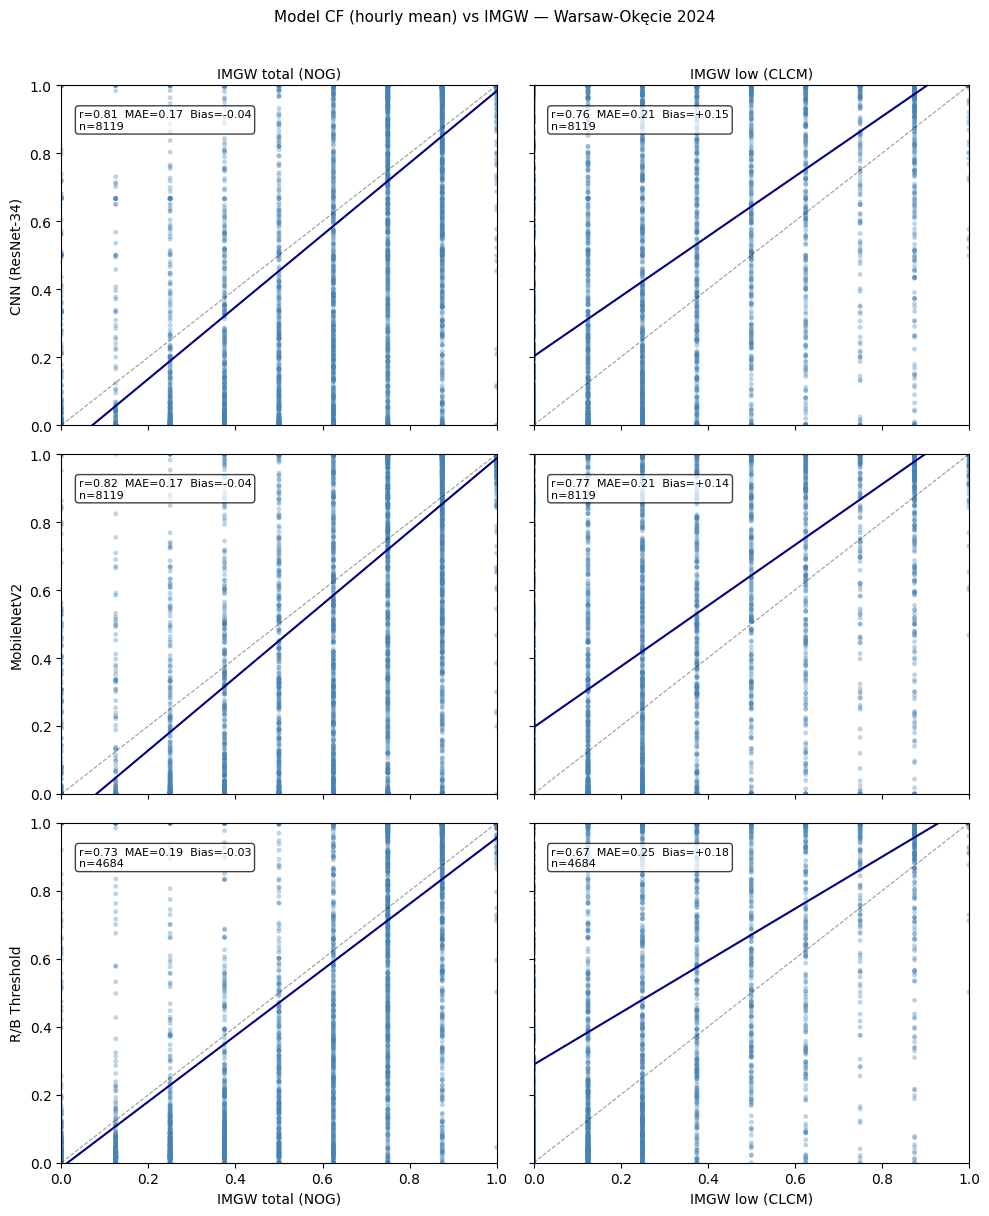

In [5]:
def compute_metrics(sub, mcol, icol):
    s = sub[[mcol, icol]].dropna()
    x, y = s[icol].values, s[mcol].values
    if len(x) < 5:
        return None
    r, _ = stats.pearsonr(x, y)
    return dict(n=len(x), r=round(r,3),
                MAE=round(float(np.mean(np.abs(y-x))),3),
                RMSE=round(float(np.sqrt(np.mean((y-x)**2))),3),
                Bias=round(float(np.mean(y-x)),3))

fig, axes = plt.subplots(len(MODEL_COLS), len(IMGW_TARGETS),
                         figsize=(10, 4*len(MODEL_COLS)), sharex=True, sharey=True)
if len(MODEL_COLS) == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('Model CF (hourly mean) vs IMGW — Warsaw-Okęcie 2024', fontsize=11, y=1.01)

for row, (mcol, mlabel) in enumerate(MODEL_COLS.items()):
    for col, (icol, ilabel) in enumerate(IMGW_TARGETS.items()):
        ax = axes[row, col]
        sub = df[[mcol, icol]].dropna()
        ax.scatter(sub[icol], sub[mcol], alpha=0.35, s=12, color='steelblue', edgecolors='none')
        m = compute_metrics(df, mcol, icol)
        if m and m['n'] > 5:
            slope, intercept, r_val, _, _ = stats.linregress(sub[icol].values, sub[mcol].values)
            xfit = np.linspace(0, 1, 100)
            ax.plot(xfit, slope*xfit + intercept, 'navy', lw=1.5)
            ax.text(0.04, 0.93,
                    f'r={m["r"]:.2f}  MAE={m["MAE"]:.2f}  Bias={m["Bias"]:+.2f}\nn={m["n"]}',
                    transform=ax.transAxes, fontsize=8, va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75))
        ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xlabel(ilabel if row == len(MODEL_COLS)-1 else '')
        ax.set_ylabel(mlabel if col == 0 else '')
        if row == 0:
            ax.set_title(ilabel, fontsize=10)

plt.tight_layout()
plt.savefig(ROOT/'outputs'/'plots'/'08_scatter_models_vs_imgw.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Time-series overlay (daytime hours)

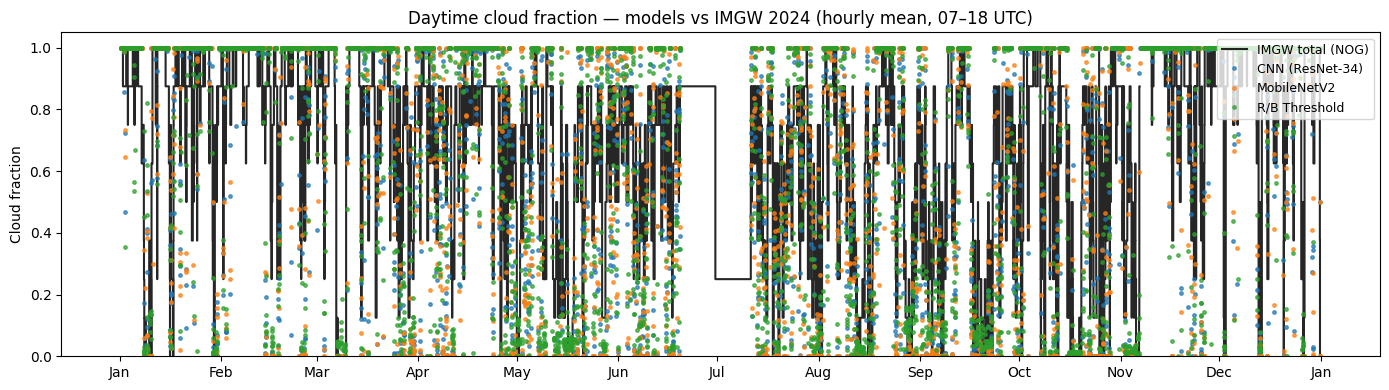

In [6]:
ts = df[(df['hour_dt'].dt.hour >= 7) & (df['hour_dt'].dt.hour <= 18)].sort_values('hour_dt')

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(ts['hour_dt'], ts['cf_imgw_total'], where='mid',
        color='black', lw=1.5, label='IMGW total (NOG)', alpha=0.85)

colours = {'cf_cnn': 'tab:blue', 'cf_mobilenet': 'tab:orange', 'cf_rb_threshold': 'tab:green'}
for mcol, mlabel in MODEL_COLS.items():
    ax.plot(ts['hour_dt'], ts[mcol], '.', ms=5,
            color=colours.get(mcol, 'grey'), label=mlabel, alpha=0.7)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel('Cloud fraction')
ax.set_title('Daytime cloud fraction — models vs IMGW 2024 (hourly mean, 07–18 UTC)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(ROOT/'outputs'/'plots'/'08_timeseries_vs_imgw.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bias by okta class

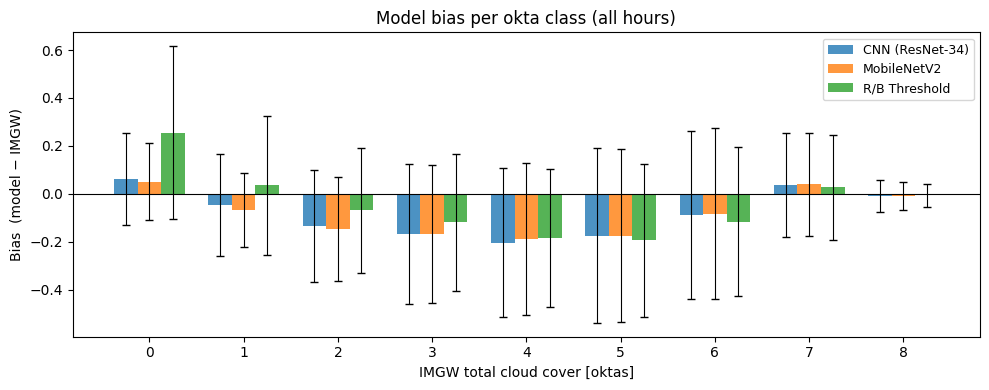

In [7]:
df['NOG_int'] = df['NOG'].round().astype('Int64')

bias_rows = []
for mcol, mlabel in MODEL_COLS.items():
    sub = df[['NOG_int', mcol, 'cf_imgw_total']].dropna().copy()
    sub['bias'] = sub[mcol] - sub['cf_imgw_total']
    grp = sub.groupby('NOG_int')['bias'].agg(['mean','std','count']).reset_index()
    grp['model'] = mlabel
    bias_rows.append(grp)

bias_df = pd.concat(bias_rows)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tab:blue', 'tab:orange', 'tab:green']
width = 0.25
oktas = sorted(bias_df['NOG_int'].dropna().unique())
x = np.arange(len(oktas))

for i, (mlabel, color) in enumerate(zip(MODEL_COLS.values(), colors)):
    sub = bias_df[bias_df['model'] == mlabel].set_index('NOG_int').reindex(oktas)
    ax.bar(x + i*width, sub['mean'], width, yerr=sub['std'],
           label=mlabel, color=color, alpha=0.8, capsize=3, error_kw={'lw': 0.8})

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels([str(int(o)) for o in oktas])
ax.set_xlabel('IMGW total cloud cover [oktas]')
ax.set_ylabel('Bias  (model − IMGW)')
ax.set_title('Model bias per okta class (all hours)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT/'outputs'/'plots'/'08_bias_per_okta.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary metrics table (stable vs all)

In [8]:
rows = []
for mcol, mlabel in MODEL_COLS.items():
    for icol, ilabel in IMGW_TARGETS.items():
        m = compute_metrics(df, mcol, icol)
        if m:
            rows.append({'Model': mlabel, 'Reference': ilabel, **m})

metrics = pd.DataFrame(rows)
metrics.to_csv(CSV_DIR / 'imgw_comparison_metrics.csv', index=False)
print(metrics.to_string(index=False))

          Model        Reference    n     r   MAE  RMSE   Bias
CNN (ResNet-34) IMGW total (NOG) 8119 0.814 0.172 0.255 -0.037
CNN (ResNet-34)  IMGW low (CLCM) 8119 0.762 0.214 0.319  0.146
    MobileNetV2 IMGW total (NOG) 8119 0.824 0.168 0.250 -0.037
    MobileNetV2  IMGW low (CLCM) 8119 0.771 0.210 0.315  0.145
  R/B Threshold IMGW total (NOG) 4684 0.731 0.192 0.276 -0.034
  R/B Threshold  IMGW low (CLCM) 4684 0.674 0.251 0.358  0.182


## 9. Distribution comparison (KDE)

## 9. Daytime-matched comparison: CNN vs R/B Threshold

R/B threshold only works when the sun is above the horizon. To compare CNN and R/B fairly we need to restrict both to **the same hours where the sun was up** — using `sun.py` from this project with the actual camera coordinates, so the daytime definition is consistent with how the models were run.

Two filters applied together:
1. Sun altitude > 0° at the camera location (from `sun_altaz`)  
2. R/B has a snap reading for that hour (data-availability guard)

In [9]:
import sys
sys.path.insert(0, str(ROOT / 'src'))
from skycamera.sun import sun_altaz
from datetime import timezone

def is_sun_up(dt):
    dt_utc = dt.to_pydatetime().replace(tzinfo=timezone.utc)
    alt, _ = sun_altaz(dt_utc)
    return alt > 0

df['sun_up'] = df['hour_dt'].apply(is_sun_up)
df_day = df[df['sun_up'] & df['cf_rb_threshold'].notna()].copy()

print(f"Total matched hours:     {len(df)}")
print(f"Hours with sun up:       {df['sun_up'].sum()}")
print(f"Daytime + R/B available: {len(df_day)}")

Total matched hours:     8161
Hours with sun up:       4063
Daytime + R/B available: 4062


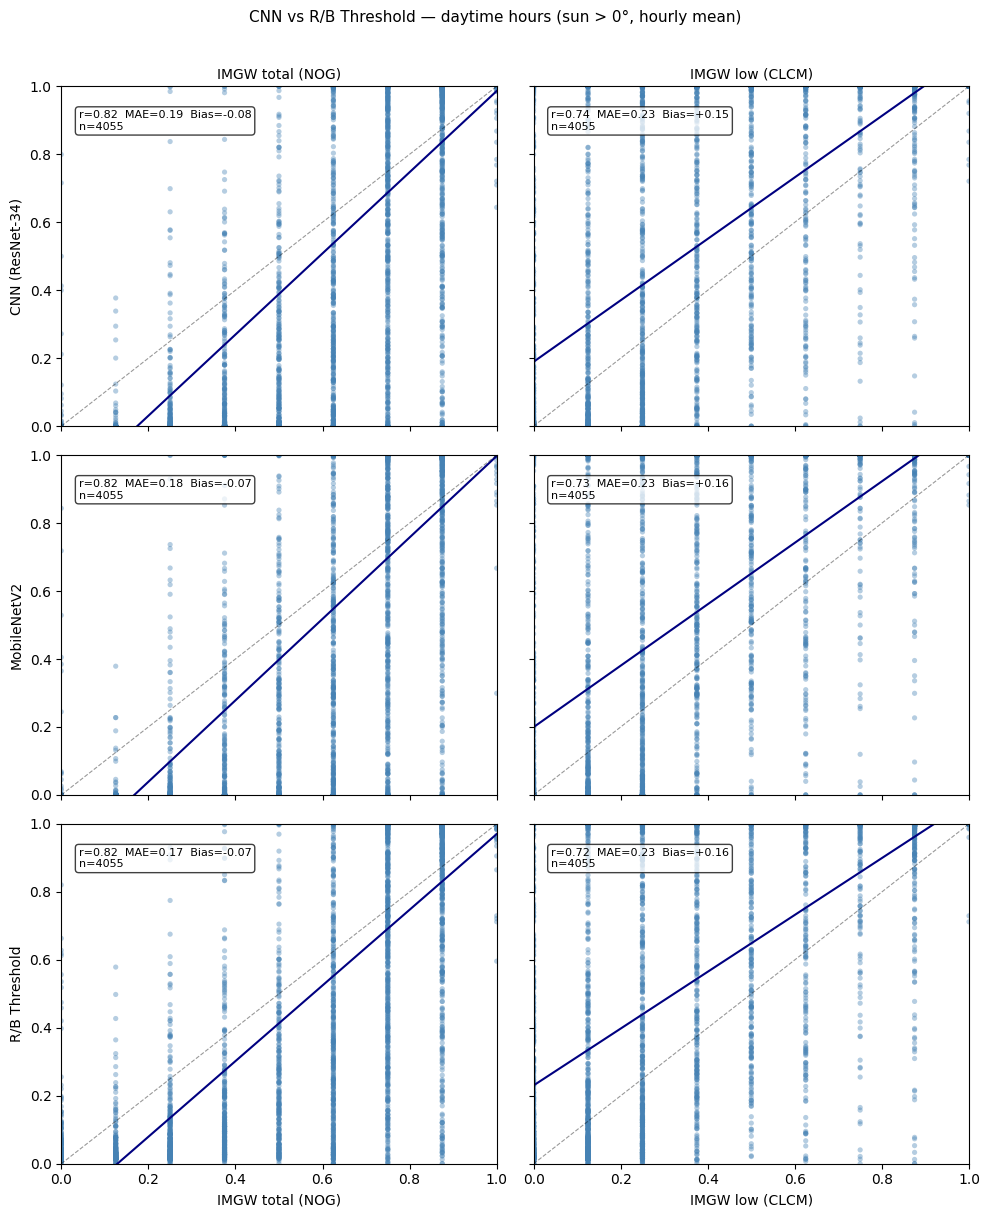


Daytime metrics (CNN vs R/B, sun > 0°, NOG reference):
Model                         n      r    MAE   RMSE    Bias
-------------------------------------------------------
CNN (ResNet-34)            4055  0.825  0.187  0.260  -0.077
MobileNetV2                4055  0.825  0.185  0.259  -0.067
R/B Threshold              4055  0.817  0.175  0.244  -0.067


In [10]:
DAY_MODELS = {k: v for k, v in MODEL_COLS.items() if k in df_day.columns}

fig, axes = plt.subplots(len(DAY_MODELS), len(IMGW_TARGETS),
                         figsize=(10, 4*len(DAY_MODELS)), sharex=True, sharey=True)
if len(DAY_MODELS) == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('CNN vs R/B Threshold — daytime hours (sun > 0°, hourly mean)', fontsize=11, y=1.01)

for row, (mcol, mlabel) in enumerate(DAY_MODELS.items()):
    for col, (icol, ilabel) in enumerate(IMGW_TARGETS.items()):
        ax = axes[row, col]
        sub = df_day[[mcol, icol]].dropna()
        ax.scatter(sub[icol], sub[mcol], alpha=0.4, s=14, color='steelblue', edgecolors='none')
        m = compute_metrics(df_day, mcol, icol)
        if m and m['n'] > 5:
            slope, intercept, r_val, _, _ = stats.linregress(sub[icol].values, sub[mcol].values)
            xfit = np.linspace(0, 1, 100)
            ax.plot(xfit, slope*xfit + intercept, 'navy', lw=1.5)
            ax.text(0.04, 0.93,
                    f'r={m["r"]:.2f}  MAE={m["MAE"]:.2f}  Bias={m["Bias"]:+.2f}\nn={m["n"]}',
                    transform=ax.transAxes, fontsize=8, va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75))
        ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xlabel(ilabel if row == len(DAY_MODELS)-1 else '')
        ax.set_ylabel(mlabel if col == 0 else '')
        if row == 0:
            ax.set_title(ilabel, fontsize=10)

plt.tight_layout()
plt.savefig(ROOT/'outputs'/'plots'/'08_scatter_daytime_matched.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDaytime metrics (CNN vs R/B, sun > 0°, NOG reference):')
print(f'{"Model":<25} {"n":>5} {"r":>6} {"MAE":>6} {"RMSE":>6} {"Bias":>7}')
print('-' * 55)
for mcol, mlabel in DAY_MODELS.items():
    m = compute_metrics(df_day, mcol, 'cf_imgw_total')
    if m:
        print(f'{mlabel:<25} {m["n"]:>5} {m["r"]:>6.3f} {m["MAE"]:>6.3f} {m["RMSE"]:>6.3f} {m["Bias"]:>7.3f}')

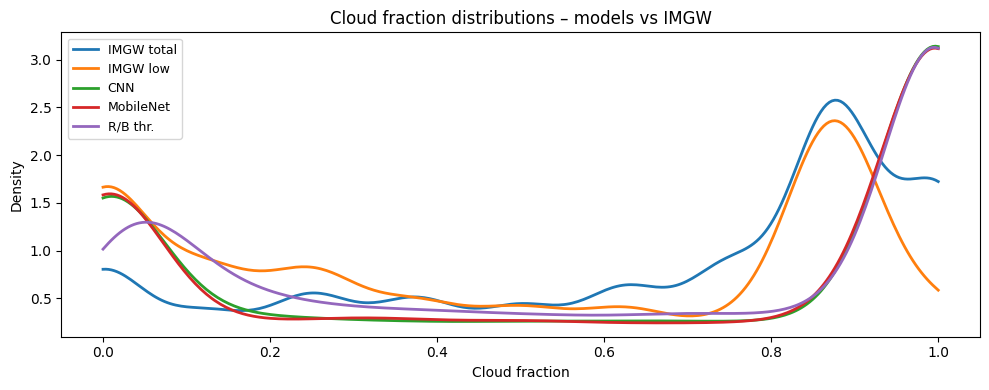

In [11]:
series = {
    'IMGW total': df['cf_imgw_total'].dropna().values,
    'IMGW low':   df['cf_imgw_low'].dropna().values,
    'CNN':        df['cf_cnn'].dropna().values,
    'MobileNet':  df['cf_mobilenet'].dropna().values,
    'R/B thr.':   df['cf_rb_threshold'].dropna().values,
}

fig, ax = plt.subplots(figsize=(10, 4))
xgrid = np.linspace(0, 1, 300)

for i, (label, vals) in enumerate(series.items()):
    if len(vals) < 10:
        continue
    kde = gaussian_kde(vals, bw_method=0.15)
    ax.plot(xgrid, kde(xgrid), lw=2, color=plt.cm.tab10.colors[i], label=label)

ax.set_xlabel('Cloud fraction')
ax.set_ylabel('Density')
ax.set_title('Cloud fraction distributions – models vs IMGW')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'plots' / '08_kde_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Monthly breakdown

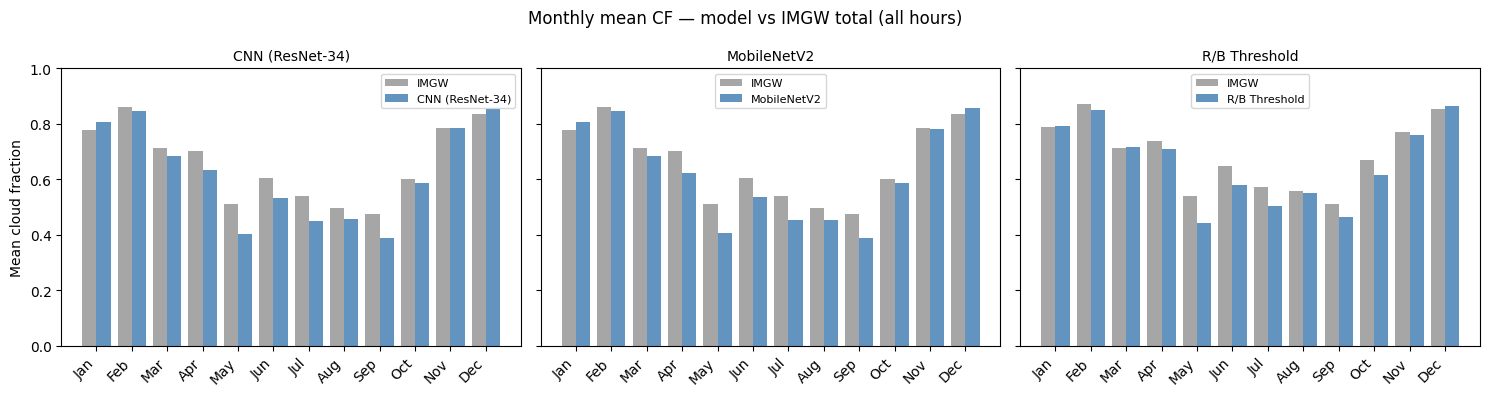

In [12]:
df['month'] = df['hour_dt'].dt.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, len(MODEL_COLS), figsize=(5*len(MODEL_COLS), 4), sharey=True)
fig.suptitle('Monthly mean CF — model vs IMGW total (all hours)', fontsize=12)

for ax, (mcol, mlabel) in zip(axes, MODEL_COLS.items()):
    sub = df[['month', mcol, 'cf_imgw_total']].dropna()
    m_model = sub.groupby('month')[mcol].mean()
    m_imgw  = sub.groupby('month')['cf_imgw_total'].mean()
    months  = sorted(sub['month'].unique())
    x = np.arange(len(months))
    ax.bar(x - 0.2, [m_imgw.get(m, np.nan)  for m in months], 0.4, label='IMGW',   color='grey',      alpha=0.7)
    ax.bar(x + 0.2, [m_model.get(m, np.nan) for m in months], 0.4, label=mlabel, color='steelblue', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([month_labels[m-1] for m in months], rotation=45, ha='right')
    ax.set_title(mlabel, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Mean cloud fraction')
plt.tight_layout()
plt.savefig(ROOT/'outputs'/'plots'/'08_monthly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ERA5 reanalysis comparison

ERA5 hourly total cloud cover (`tcc`), low cloud cover (`lcc`), medium cloud cover (`mcc`),
and high cloud cover (`hcc`) for 2024. Data is on a global grid — we select the nearest
grid point to the camera location (Warsaw: lat=52.2411°N, lon=21.0327°E).

ERA5 `tcc` is a fraction [0–1] representing the total cloud cover fraction,
already comparable to our model output without conversion.

In [13]:
def load_era5_warsaw(nc_path, var):
    """Load ERA5 .nc, find nearest point to Warsaw by index, return hourly DataFrame."""
    ds = xr.open_dataset(nc_path)
    lats = ds['latitude'].values
    lons = ds['longitude'].values
    dists = np.sqrt((lats - CAMERA_LAT)**2 + (lons - CAMERA_LON)**2)
    idx = int(np.argmin(dists))
    series = ds[var].values[:, idx]        # (valid_time,)
    times  = ds['valid_time'].values
    df_out = pd.DataFrame({'datetime': pd.to_datetime(times), f'era5_{var}': series.astype(float)})
    df_out['datetime'] = df_out['datetime'].dt.tz_localize(None)
    return df_out.sort_values('datetime').reset_index(drop=True)

era5_vars = {'tcc': 'Total CC', 'lcc': 'Low CC', 'mcc': 'Medium CC', 'hcc': 'High CC'}
era5_dfs  = {}

for var, label in era5_vars.items():
    nc_file = ERA5_DIR / f'ERA5-{var}-2024.nc'
    if nc_file.exists():
        era5_dfs[var] = load_era5_warsaw(nc_file, var)
        df_v = era5_dfs[var]
        print(f'ERA5 {label} ({var}): {len(df_v)} rows  '
              f'mean={df_v[f"era5_{var}"].mean():.3f}  '
              f'range=[{df_v[f"era5_{var}"].min():.3f}, {df_v[f"era5_{var}"].max():.3f}]')
    else:
        print(f'Missing: {nc_file}')

# Show which grid point was selected
ds_tmp = xr.open_dataset(ERA5_DIR / 'ERA5-tcc-2024.nc')
lats = ds_tmp['latitude'].values; lons = ds_tmp['longitude'].values
idx = int(np.argmin(np.sqrt((lats-CAMERA_LAT)**2 + (lons-CAMERA_LON)**2)))
print(f'\nNearest ERA5 point: lat={lats[idx]:.4f}° lon={lons[idx]:.4f}°  '
      f'(Δlat={lats[idx]-CAMERA_LAT:+.4f}° Δlon={lons[idx]-CAMERA_LON:+.4f}°)')

ERA5 Total CC (tcc): 8784 rows  mean=0.672  range=[0.000, 1.000]
ERA5 Low CC (lcc): 8784 rows  mean=0.372  range=[0.000, 1.000]
ERA5 Medium CC (mcc): 8784 rows  mean=0.321  range=[0.000, 1.000]
ERA5 High CC (hcc): 8784 rows  mean=0.387  range=[0.000, 1.000]

Nearest ERA5 point: lat=52.2500° lon=21.0000°  (Δlat=+0.0089° Δlon=-0.0327°)


Matched hours (camera hourly mean + ERA5): 8161


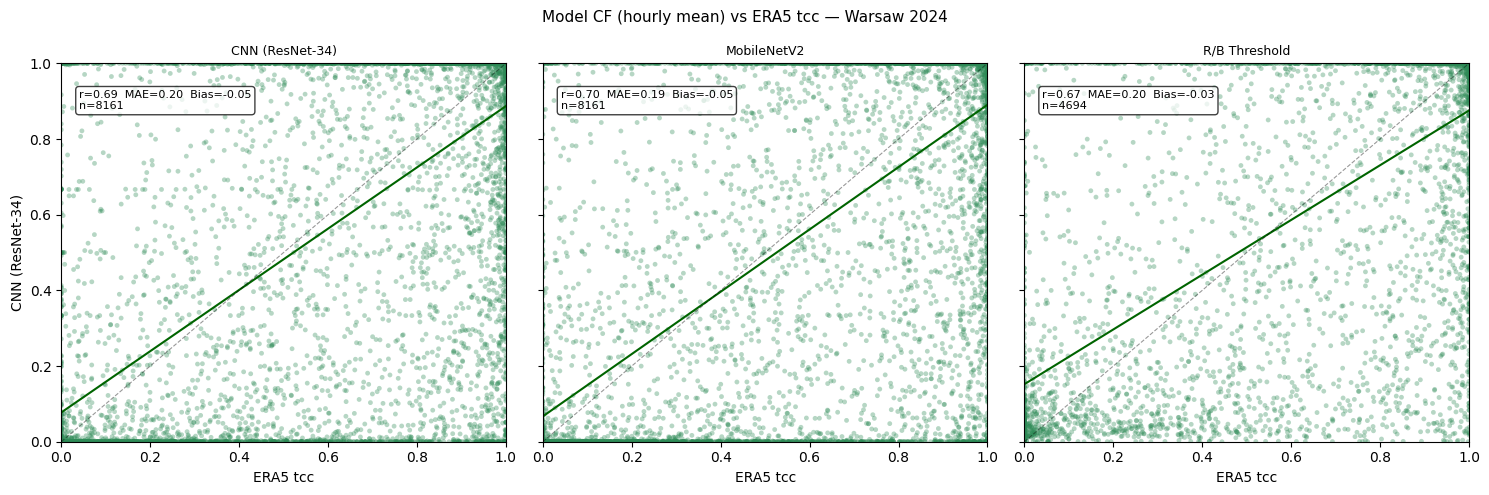

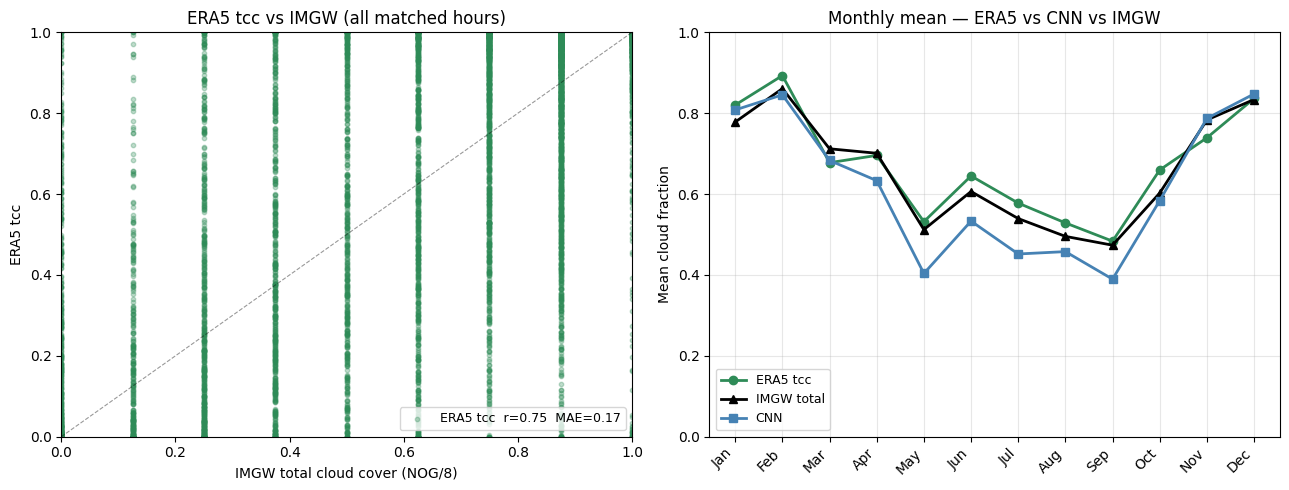


ERA5 tcc vs model metrics:
Model                         n      r    MAE   RMSE    Bias
-------------------------------------------------------
CNN (ResNet-34)            8161  0.694  0.196  0.324  -0.052
MobileNetV2                8161  0.705  0.193  0.319  -0.052
R/B Threshold              4694  0.668  0.197  0.317  -0.033

ERA5 tcc vs IMGW total:  r=0.751  MAE=0.170


In [14]:
if 'tcc' not in era5_dfs:
    print('ERA5 tcc not loaded — skipping.')
else:
    era5_tcc = era5_dfs['tcc'].rename(columns={'datetime': 'hour_dt'})
    df_era5  = df.merge(era5_tcc, on='hour_dt', how='inner')
    print(f'Matched hours (camera hourly mean + ERA5): {len(df_era5)}')

    # --- Scatter: each model vs ERA5 tcc ---
    fig, axes = plt.subplots(1, len(MODEL_COLS), figsize=(5*len(MODEL_COLS), 5), sharey=True)
    fig.suptitle('Model CF (hourly mean) vs ERA5 tcc — Warsaw 2024', fontsize=11)
    for ax, (mcol, mlabel) in zip(axes, MODEL_COLS.items()):
        sub = df_era5[[mcol, 'era5_tcc']].dropna()
        ax.scatter(sub['era5_tcc'], sub[mcol], alpha=0.35, s=12, color='seagreen', edgecolors='none')
        m = compute_metrics(df_era5, mcol, 'era5_tcc')
        if m and m['n'] > 5:
            slope, intercept, *_ = stats.linregress(sub['era5_tcc'].values, sub[mcol].values)
            xfit = np.linspace(0, 1, 100)
            ax.plot(xfit, slope*xfit + intercept, 'darkgreen', lw=1.5)
            ax.text(0.04, 0.93,
                    f'r={m["r"]:.2f}  MAE={m["MAE"]:.2f}  Bias={m["Bias"]:+.2f}\nn={m["n"]}',
                    transform=ax.transAxes, fontsize=8, va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75))
        ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xlabel('ERA5 tcc'); ax.set_ylabel(mlabel if ax == axes[0] else '')
        ax.set_title(mlabel, fontsize=9)
    plt.tight_layout()
    plt.savefig(ROOT/'outputs'/'plots'/'08_scatter_models_vs_era5.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- ERA5 tcc vs IMGW + monthly comparison ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: ERA5 tcc vs IMGW total
    ax = axes[0]
    merged_e = era5_tcc.merge(
        imgw[['datetime','cf_imgw_total']].rename(columns={'datetime':'hour_dt'}),
        on='hour_dt', how='inner'
    ).dropna()
    x, y = merged_e['cf_imgw_total'].values, merged_e['era5_tcc'].values
    r_val, _ = stats.pearsonr(x, y)
    mae = np.mean(np.abs(y - x))
    ax.scatter(x, y, alpha=0.3, s=10, color='seagreen',
               label=f'ERA5 tcc  r={r_val:.2f}  MAE={mae:.2f}')
    ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
    ax.set_xlabel('IMGW total cloud cover (NOG/8)')
    ax.set_ylabel('ERA5 tcc')
    ax.set_title('ERA5 tcc vs IMGW (all matched hours)')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)

    # Right: monthly mean — ERA5 vs CNN vs IMGW
    ax = axes[1]
    df_era5['month'] = df_era5['hour_dt'].dt.month
    months  = sorted(df_era5['month'].unique())
    x_pos   = np.arange(len(months))
    m_era5  = df_era5.groupby('month')['era5_tcc'].mean()
    m_imgw  = df_era5.groupby('month')['cf_imgw_total'].mean()
    ax.plot(x_pos, [m_era5.get(m, np.nan) for m in months], 'o-', color='seagreen', label='ERA5 tcc', lw=2)
    ax.plot(x_pos, [m_imgw.get(m, np.nan) for m in months], '^-', color='black',    label='IMGW total', lw=2)
    if 'cf_cnn' in df_era5.columns:
        m_cnn = df_era5.groupby('month')['cf_cnn'].mean()
        ax.plot(x_pos, [m_cnn.get(m, np.nan) for m in months], 's-', color='steelblue', label='CNN', lw=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([month_labels[m-1] for m in months], rotation=45, ha='right')
    ax.set_ylabel('Mean cloud fraction')
    ax.set_title('Monthly mean — ERA5 vs CNN vs IMGW')
    ax.legend(fontsize=9); ax.set_ylim(0,1); ax.grid(alpha=0.3)

    fig.tight_layout()
    plt.savefig(ROOT/'outputs'/'plots'/'08_era5_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Summary metrics ---
    print('\nERA5 tcc vs model metrics:')
    print(f'{"Model":<25} {"n":>5} {"r":>6} {"MAE":>6} {"RMSE":>6} {"Bias":>7}')
    print('-' * 55)
    for mcol, mlabel in MODEL_COLS.items():
        m = compute_metrics(df_era5, mcol, 'era5_tcc')
        if m:
            print(f'{mlabel:<25} {m["n"]:>5} {m["r"]:>6.3f} {m["MAE"]:>6.3f} {m["RMSE"]:>6.3f} {m["Bias"]:>7.3f}')
    print(f'\nERA5 tcc vs IMGW total:  r={r_val:.3f}  MAE={mae:.3f}')

## 12. ERA5 layer comparison — all sources

Compare camera CF against each ERA5 layer (tcc, lcc, mcc, hcc) and IMGW references side by side.
Helps understand which cloud layer drives camera CF signal.

Hours with camera + IMGW + all ERA5 layers: 8161

All models × all references (r / MAE):

Pearson r:
Reference        ERA5 hcc  ERA5 lcc  ERA5 mcc  ERA5 tcc  IMGW low (CLCM)  IMGW total (NOG)
Model                                                                                     
CNN (ResNet-34)     0.320     0.557     0.504     0.694            0.762             0.814
MobileNetV2         0.325     0.561     0.511     0.705            0.771             0.824
R/B Threshold       0.348     0.518     0.488     0.668            0.674             0.731

MAE:
Reference        ERA5 hcc  ERA5 lcc  ERA5 mcc  ERA5 tcc  IMGW low (CLCM)  IMGW total (NOG)
Model                                                                                     
CNN (ResNet-34)     0.389     0.309     0.354     0.196            0.214             0.172
MobileNetV2         0.388     0.308     0.351     0.193            0.210             0.168
R/B Threshold       0.376     0.343     0.363     0.197            0.251  

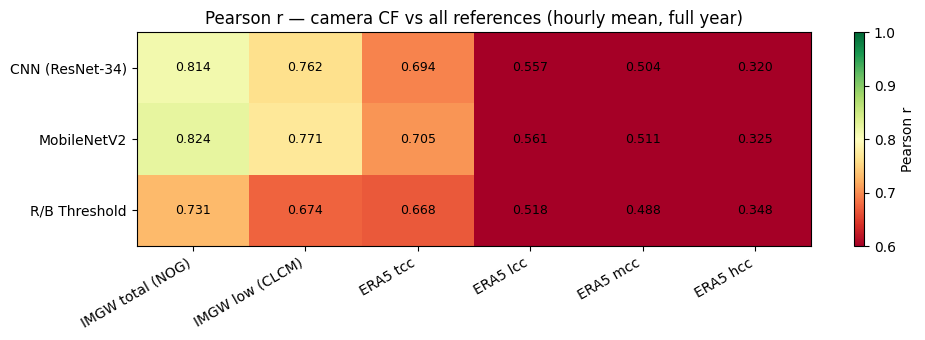

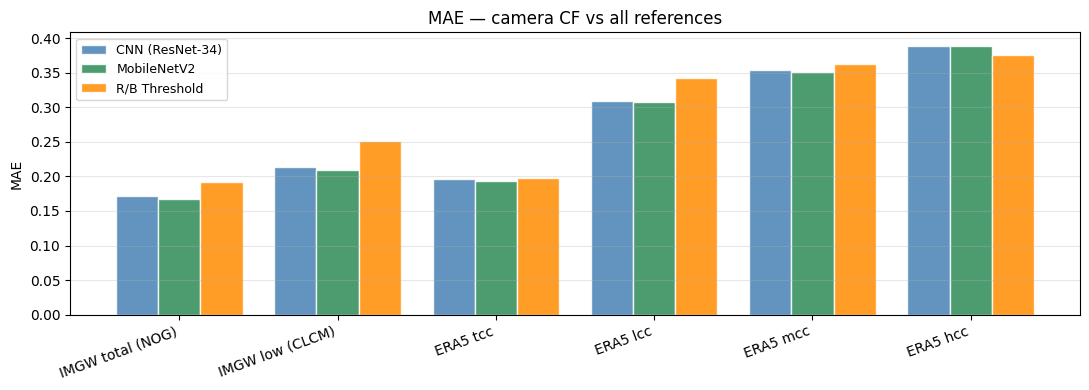

In [15]:
# Build a wide table: all ERA5 layers + IMGW merged on hour
era5_wide = None
for var in ['tcc', 'lcc', 'mcc', 'hcc']:
    if var not in era5_dfs:
        continue
    tmp = era5_dfs[var].rename(columns={'datetime': 'hour_dt'})
    era5_wide = tmp if era5_wide is None else era5_wide.merge(tmp, on='hour_dt', how='inner')

if era5_wide is None:
    print('No ERA5 data loaded.')
else:
    df_all_refs = df.merge(era5_wide, on='hour_dt', how='inner')
    print(f'Hours with camera + IMGW + all ERA5 layers: {len(df_all_refs)}')

    # All reference columns (IMGW + ERA5 layers)
    ref_cols = {
        'IMGW total (NOG)': 'cf_imgw_total',
        'IMGW low (CLCM)':  'cf_imgw_low',
        'ERA5 tcc':         'era5_tcc',
        'ERA5 lcc':         'era5_lcc',
        'ERA5 mcc':         'era5_mcc',
        'ERA5 hcc':         'era5_hcc',
    }
    ref_cols = {k: v for k, v in ref_cols.items() if v in df_all_refs.columns}

    # ── Metrics table: all models × all references ──────────────────────
    rows = []
    for mcol, mlabel in MODEL_COLS.items():
        for rlabel, rcol in ref_cols.items():
            m = compute_metrics(df_all_refs, mcol, rcol)
            if m:
                rows.append({'Model': mlabel, 'Reference': rlabel, **m})
    df_layer = pd.DataFrame(rows)
    print('\nAll models × all references (r / MAE):')
    pivot_r   = df_layer.pivot(index='Model', columns='Reference', values='r').round(3)
    pivot_mae = df_layer.pivot(index='Model', columns='Reference', values='MAE').round(3)
    print('\nPearson r:')
    print(pivot_r.to_string())
    print('\nMAE:')
    print(pivot_mae.to_string())

    # ── Heatmap: Pearson r ───────────────────────────────────────────────
    ref_order   = list(ref_cols.keys())
    model_order = list(MODEL_COLS.values())
    r_matrix = np.full((len(model_order), len(ref_order)), np.nan)
    for i, mlabel in enumerate(model_order):
        for j, rlabel in enumerate(ref_order):
            sub = df_layer[(df_layer['Model']==mlabel) & (df_layer['Reference']==rlabel)]
            if len(sub):
                r_matrix[i, j] = sub['r'].values[0]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    im = ax.imshow(r_matrix, vmin=0.6, vmax=1.0, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, label='Pearson r')
    ax.set_xticks(range(len(ref_order)));   ax.set_xticklabels(ref_order, rotation=30, ha='right')
    ax.set_yticks(range(len(model_order))); ax.set_yticklabels(model_order)
    for i in range(len(model_order)):
        for j in range(len(ref_order)):
            if not np.isnan(r_matrix[i,j]):
                ax.text(j, i, f'{r_matrix[i,j]:.3f}', ha='center', va='center', fontsize=9,
                        color='black' if r_matrix[i,j] < 0.9 else 'white')
    ax.set_title('Pearson r — camera CF vs all references (hourly mean, full year)')
    fig.tight_layout()
    fig.savefig(ROOT/'outputs'/'plots'/'08_layer_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Bar chart: MAE per reference, grouped by model ───────────────────
    fig, ax = plt.subplots(figsize=(11, 4))
    x     = np.arange(len(ref_order))
    width = 0.8 / len(MODEL_COLS)
    colours_m = ['steelblue', 'seagreen', 'darkorange']
    for i, (mcol, mlabel) in enumerate(MODEL_COLS.items()):
        maes = []
        for rlabel in ref_order:
            sub = df_layer[(df_layer['Model']==mlabel) & (df_layer['Reference']==rlabel)]
            maes.append(sub['MAE'].values[0] if len(sub) else np.nan)
        ax.bar(x + i*width - 0.4 + width/2, maes, width,
               label=mlabel, color=colours_m[i], alpha=0.85, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(ref_order, rotation=20, ha='right')
    ax.set_ylabel('MAE'); ax.set_title('MAE — camera CF vs all references')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(ROOT/'outputs'/'plots'/'08_layer_mae_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. CNN vs R/B threshold — where does CNN actually win?

R/B threshold is competitive overall (r=0.817 daytime) but physically limited.
This section breaks down CNN advantage by condition: okta class, season, time of day, and CF regime.

Overall: CNN wins 24.3% of hours vs R/B (n=4055)
Mean |err| CNN=0.1873  R/B=0.1750


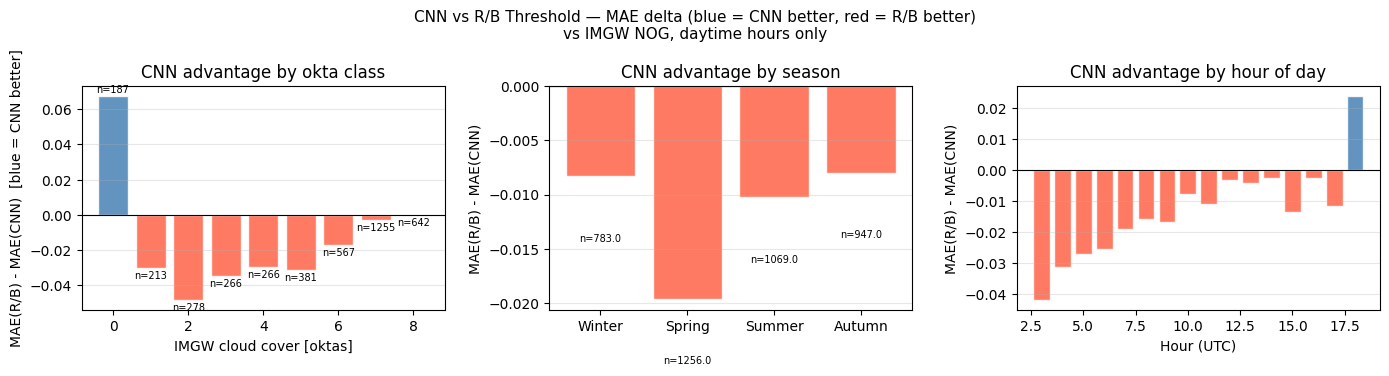

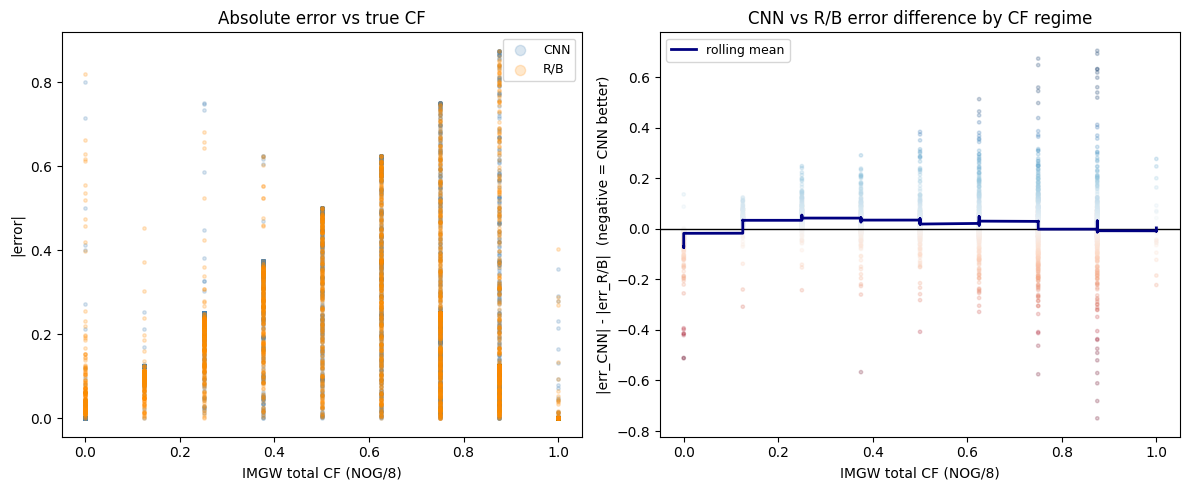


CNN win rate (lower |error| vs IMGW NOG) by condition:
Condition                   win%     DMAE     n
-----------------------------------------------
  Winter                   12.0%  -0.0083    783
  Spring                   26.2%  -0.0197   1256
  Summer                   31.0%  -0.0102   1069
  Autumn                   24.6%  -0.0080    947

  Okta 0                    98.4%  +0.0672    187
  Okta 1                     5.6%  -0.0301    213
  Okta 2                     7.9%  -0.0482    278
  Okta 3                    23.3%  -0.0347    266
  Okta 4                    32.0%  -0.0297    266
  Okta 5                    34.4%  -0.0316    381
  Okta 6                    35.8%  -0.0173    567
  Okta 7                    19.0%  -0.0027   1255
  Okta 8                     7.8%  -0.0003    642


In [16]:
# Use daytime-matched hours where both CNN and R/B are available
if 'cf_rb_threshold' not in df_day.columns or 'cf_cnn' not in df_day.columns:
    print('Need both cf_cnn and cf_rb_threshold in df_day.')
else:
    cmp = df_day[['hour_dt', 'cf_cnn', 'cf_rb_threshold', 'cf_imgw_total', 'NOG']].dropna().copy()
    cmp['err_cnn'] = (cmp['cf_cnn'] - cmp['cf_imgw_total']).abs()
    cmp['err_rb']  = (cmp['cf_rb_threshold'] - cmp['cf_imgw_total']).abs()
    cmp['cnn_wins']  = cmp['err_cnn'] < cmp['err_rb']   # CNN has lower abs error
    cmp['month']     = cmp['hour_dt'].dt.month
    cmp['hour']      = cmp['hour_dt'].dt.hour
    cmp['season']    = cmp['month'].map({12:'Winter',1:'Winter',2:'Winter',
                                          3:'Spring',4:'Spring',5:'Spring',
                                          6:'Summer',7:'Summer',8:'Summer',
                                          9:'Autumn',10:'Autumn',11:'Autumn'})
    cmp['NOG_int']   = cmp['NOG'].round().astype(int)

    overall_cnn_win = cmp['cnn_wins'].mean()
    print(f'Overall: CNN wins {overall_cnn_win*100:.1f}% of hours vs R/B (n={len(cmp)})')
    print(f'Mean |err| CNN={cmp["err_cnn"].mean():.4f}  R/B={cmp["err_rb"].mean():.4f}')

    # ── 1. CNN win rate + MAE delta by okta class ────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Okta class
    ax = axes[0]
    okta_stats = cmp.groupby('NOG_int').agg(
        win_rate=('cnn_wins', 'mean'),
        mae_cnn=('err_cnn', 'mean'),
        mae_rb=('err_rb', 'mean'),
        n=('cnn_wins', 'count'),
    ).reset_index()
    okta_stats['mae_delta'] = okta_stats['mae_rb'] - okta_stats['mae_cnn']  # positive = CNN better
    bars = ax.bar(okta_stats['NOG_int'], okta_stats['mae_delta'],
                  color=['steelblue' if d > 0 else 'tomato' for d in okta_stats['mae_delta']],
                  alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    for bar, row in zip(bars, okta_stats.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (0.002 if row.mae_delta >= 0 else -0.006),
                f'n={row.n}', ha='center', fontsize=7)
    ax.set_xlabel('IMGW cloud cover [oktas]')
    ax.set_ylabel('MAE(R/B) - MAE(CNN)  [blue = CNN better]')
    ax.set_title('CNN advantage by okta class')
    ax.grid(axis='y', alpha=0.3)

    # Season
    ax = axes[1]
    season_order = ['Winter','Spring','Summer','Autumn']
    season_stats = cmp.groupby('season').agg(
        win_rate=('cnn_wins','mean'),
        mae_cnn=('err_cnn','mean'),
        mae_rb=('err_rb','mean'),
        n=('cnn_wins','count'),
    ).reindex(season_order)
    season_stats['mae_delta'] = season_stats['mae_rb'] - season_stats['mae_cnn']
    x = np.arange(len(season_order))
    bars = ax.bar(x, season_stats['mae_delta'],
                  color=['steelblue' if d > 0 else 'tomato' for d in season_stats['mae_delta']],
                  alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    for bar, (s, row) in zip(bars, season_stats.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (0.002 if row.mae_delta >= 0 else -0.006),
                f'n={row.n}', ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(season_order)
    ax.set_ylabel('MAE(R/B) - MAE(CNN)')
    ax.set_title('CNN advantage by season')
    ax.grid(axis='y', alpha=0.3)

    # Hour of day
    ax = axes[2]
    hour_stats = cmp.groupby('hour').agg(
        mae_cnn=('err_cnn','mean'),
        mae_rb=('err_rb','mean'),
        n=('cnn_wins','count'),
    ).reset_index()
    hour_stats['mae_delta'] = hour_stats['mae_rb'] - hour_stats['mae_cnn']
    ax.bar(hour_stats['hour'], hour_stats['mae_delta'],
           color=['steelblue' if d > 0 else 'tomato' for d in hour_stats['mae_delta']],
           alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('MAE(R/B) - MAE(CNN)')
    ax.set_title('CNN advantage by hour of day')
    ax.grid(axis='y', alpha=0.3)

    fig.suptitle('CNN vs R/B Threshold — MAE delta (blue = CNN better, red = R/B better)\nvs IMGW NOG, daytime hours only',
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(ROOT/'outputs'/'plots'/'08_cnn_vs_rb_conditions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 2. Scatter of errors: does CNN correct R/B overestimates? ────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.scatter(cmp['cf_imgw_total'], cmp['err_cnn'],  alpha=0.2, s=6, color='steelblue', label='CNN')
    ax.scatter(cmp['cf_imgw_total'], cmp['err_rb'],   alpha=0.2, s=6, color='darkorange', label='R/B')
    ax.set_xlabel('IMGW total CF (NOG/8)'); ax.set_ylabel('|error|')
    ax.set_title('Absolute error vs true CF')
    ax.legend(fontsize=9, markerscale=3)

    ax = axes[1]
    # CNN error - R/B error: positive = R/B better, negative = CNN better
    cmp['err_diff'] = cmp['err_cnn'] - cmp['err_rb']
    ax.scatter(cmp['cf_imgw_total'], cmp['err_diff'], alpha=0.2, s=6,
               c=cmp['err_diff'], cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('IMGW total CF (NOG/8)')
    ax.set_ylabel('|err_CNN| - |err_R/B|  (negative = CNN better)')
    ax.set_title('CNN vs R/B error difference by CF regime')

    # Rolling mean to show trend
    cmp_sorted = cmp.sort_values('cf_imgw_total')
    roll = cmp_sorted['err_diff'].rolling(200, center=True, min_periods=50).mean()
    ax.plot(cmp_sorted['cf_imgw_total'].values, roll.values, 'navy', lw=2, label='rolling mean')
    ax.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(ROOT/'outputs'/'plots'/'08_cnn_vs_rb_error_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 3. Summary: CNN win rate per condition ───────────────────────────
    print('\nCNN win rate (lower |error| vs IMGW NOG) by condition:')
    print(f'{"Condition":<25} {"win%":>6} {"DMAE":>8} {"n":>5}')
    print('-' * 47)
    for s in season_order:
        sub = cmp[cmp['season']==s]
        print(f'  {s:<23} {sub["cnn_wins"].mean()*100:>5.1f}%  '
              f'{(sub["err_rb"]-sub["err_cnn"]).mean():>+7.4f}  {len(sub):>5}')
    print()
    for okta in sorted(cmp['NOG_int'].unique()):
        sub = cmp[cmp['NOG_int']==okta]
        if len(sub) < 10: continue
        print(f'  Okta {okta:<19} {sub["cnn_wins"].mean()*100:>5.1f}%  '
              f'{(sub["err_rb"]-sub["err_cnn"]).mean():>+7.4f}  {len(sub):>5}')